# Supplementary Figure 6: Workflow for SFC and HSI phasor analysis of MLV comparison between platforms

**Description:**


## 1. Import Dependencies

This section imports all required libraries for loading data, phasor computation, and plotting.

In [21]:
import os
from typing import Optional, Sequence, Tuple

import fcsparser
import matplotlib.pyplot as plt
import numpy as np
import tifffile
from IPython.display import display
from matplotlib.patches import Wedge
from PIL import Image
from phasorpy.filter import phasor_filter_median, phasor_threshold
from phasorpy.phasor import phasor_from_signal, phasor_to_polar
from phasorpy.plot import PhasorPlot
from scipy.ndimage import rotate, zoom

plt.style.use("default")

## Configure Inputs

This section defines all user-editable parameters required to run the analysis for both platforms and both conditions.

Use this section whenever you switch files, conditions, or acquisition settings.

### Global parameter

- `CONDITIONS`
List of condition names to process. The execution cells loop over this list.
Change this when you want to add/remove conditions (for example, adding `DPPC 10%`).

### Spectral axis parameters

- `SFC_WAVELENGTHS`
Wavelengths (nm) for SFC spectral channels. Length must match the number of spectral channels in the SFC files.
Change this only if your SFC acquisition channel definition changes.

- `HSI_WAVELENGTHS`
Wavelengths (nm) for HSI spectral channels. Length should match the lambda channels in the HSI file.
Change this if your microscope lambda scan range or step changes.

### SFC input mapping

- `SFC_INPUTS`
Dictionary that maps each condition name to its SFC file configuration.
Each condition entry contains:
- `data_path`: full path to the `.fcs` file or to a folder containing `.fcs` files.
- `filename`: optional file name to pick inside `data_path` if `data_path` is a folder. Keep `None` when `data_path` is already a direct file path.

Change `SFC_INPUTS` when:
- You use different SFC files for the same conditions.
- You add new conditions to `CONDITIONS`.

### HSI input mapping

- `HSI_INPUTS`
Dictionary that maps each condition name to its HSI file configuration.
Each condition entry contains:
- `data_path`: full path to the `.tif` HSI file (or folder containing `.tif` files).
- `filename`: optional file name to pick inside `data_path` when it is a folder. Keep `None` for direct file paths.
- `mask_path`: path to the binary mask image used to restrict analysis to the region of interest.

Change `HSI_INPUTS` when:
- You use different HSI files for the same conditions.
- You change segmentation masks.
- You add new conditions to `CONDITIONS`.

### Output parameter

- `OUTPUT_FOLDER`
Directory where exported figures are saved (in save/export cells).
Change this when you want figures written to a different destination folder.

### Consistency rules

- Every condition listed in `CONDITIONS` must exist as a key in both `SFC_INPUTS` and `HSI_INPUTS`.
- Keep condition names exactly identical across `CONDITIONS`, `SFC_INPUTS`, and `HSI_INPUTS` (case and spacing).
- If a file is missing or a path is wrong, update only this section; analysis cells can remain unchanged.

In [ ]:
# Two-condition setup for each platform
CONDITIONS = ["DPPC 0%", "DOPC 0%"]

SFC_WAVELENGTHS = [
    428,
    443,
    458,
    473,
    508,
    525,
    542,
    581,
    598,
    615,
    664,
    692,
    720,
    750,
    780,
    812,
]
HSI_WAVELENGTHS = [
    422,
    432,
    442,
    452,
    462,
    472,
    482,
    492,
    502,
    512,
    522,
    532,
    542,
    552,
    562,
    572,
    582,
    592,
    602,
    612,
    622,
    632,
    642,
    652,
    662,
    672,
    682,
    692,
]

SFC_INPUTS = {
    "DPPC 0%": {
        "data_path": "../data/SFC/MLVs/Pre-gated/MLVs 1/DPPC Chol 0%.fcs",
        "filename": None,
    },
    "DOPC 0%": {
        "data_path": "../data/SFC/MLVs/Pre-gated/MLVs 1/DOPC Chol 0%.fcs",
        "filename": None,
    },
}

HSI_INPUTS = {
    "DPPC 0%": {
        "data_path": "../data/HSI/MVLs/MLVs 1",
        "filename": "DPPC 0 Chol_4.lsm",
        "mask_path": "../data/HSI/MVLs/MLVs 1/mask/mask_DPPC 0 Chol_4.png",
    },
    "DOPC 0%": {
        "data_path": "../data/HSI/MVLs/MLVs 1",
        "filename": "DOPC 0 Chol_2.lsm",
        "mask_path": "../data/HSI/MVLs/MLVs 1/mask/mask_DOPC 0 Chol_2.png",
    },
}

OUTPUT_FOLDER = "Supp_Fig_6"

## Define Shared and Analysis Functions

This cell defines compact reusable functions that generate the final spectral, phasor, and phase-image outputs for both SFC and HSI.

In [23]:
def resolve_input_file(
    data_path: str, filename: Optional[str], extension: str
) -> Tuple[str, str]:
    if os.path.isfile(data_path) and data_path.lower().endswith(extension.lower()):
        return data_path, os.path.splitext(os.path.basename(data_path))[0]

    if filename is None:
        files = sorted(
            f for f in os.listdir(data_path) if f.lower().endswith(extension.lower())
        )
        if not files:
            raise FileNotFoundError(f"No {extension} files found in {data_path}")
        filename = files[0]

    return os.path.join(data_path, filename), os.path.splitext(filename)[0]


def wavelength_to_rgb(wavelength: float) -> Tuple[float, float, float]:
    gamma = 0.8
    wavelength = min(max(wavelength, 380), 780)

    if 380 <= wavelength < 440:
        red, green, blue = -(wavelength - 440) / 60, 0.0, 1.0
    elif 440 <= wavelength < 490:
        red, green, blue = 0.0, (wavelength - 440) / 50, 1.0
    elif 490 <= wavelength < 510:
        red, green, blue = 0.0, 1.0, -(wavelength - 510) / 20
    elif 510 <= wavelength < 580:
        red, green, blue = (wavelength - 510) / 70, 1.0, 0.0
    elif 580 <= wavelength < 645:
        red, green, blue = 1.0, -(wavelength - 645) / 65, 0.0
    else:
        red, green, blue = 1.0, 0.0, 0.0

    if 380 <= wavelength < 420:
        factor = 0.3 + 0.7 * (wavelength - 380) / 40
    elif 420 <= wavelength <= 700:
        factor = 1.0
    else:
        factor = 0.3 + 0.7 * (780 - wavelength) / 80

    return tuple((np.array([red, green, blue]) * factor) ** gamma)


def fill_colored_spectrum(
    ax, wavelengths: Sequence[float], signal: np.ndarray, alpha: float = 0.7
) -> None:
    x = np.arange(len(wavelengths))
    colors = [wavelength_to_rgb(w) for w in wavelengths]
    for i in range(len(wavelengths) - 1):
        color = tuple((np.array(colors[i]) + np.array(colors[i + 1])) / 2)
        ax.fill(
            [x[i], x[i + 1], x[i + 1], x[i]],
            [0, 0, signal[i + 1], signal[i]],
            color=color,
            alpha=alpha,
            edgecolor="none",
        )


def rotate_flip(arr: np.ndarray, order: int = 1, cval: float = np.nan) -> np.ndarray:
    return np.fliplr(
        rotate(arr, 180, axes=(0, 1), reshape=True, order=order, cval=cval)
    )


def load_binary_mask(mask_path: str, target_shape: Tuple[int, int]) -> np.ndarray:
    mask = np.array(Image.open(mask_path).convert("L")) > 0
    mask = rotate_flip(mask.astype(float), order=0, cval=0) > 0.5
    if mask.shape != target_shape:
        factors = (target_shape[0] / mask.shape[0], target_shape[1] / mask.shape[1])
        mask = zoom(mask.astype(float), factors, order=0) > 0.5
    return mask


def add_phase_arc(
    ax,
    phase_min: float,
    phase_max: float,
    cmap_name: str,
    outer_radius: float,
    inner_radius: float,
) -> None:
    if phase_max <= phase_min:
        phase_max = phase_min + 1.0
    cmap = plt.get_cmap(cmap_name)
    norm = plt.Normalize(phase_min, phase_max)
    step = 0.2
    n_segments = max(1, int((phase_max - phase_min) / step))
    for i in range(n_segments):
        t1 = phase_min + i * step
        t2 = phase_min + (i + 1) * step
        color = cmap(norm((t1 + t2) * 0.5))
        ax.add_patch(
            Wedge(
                (0, 0),
                outer_radius,
                t1,
                t2,
                width=outer_radius - inner_radius,
                facecolor=color,
                edgecolor=color,
                linewidth=0,
            )
        )


def add_scale_bar(
    ax, shape: Tuple[int, int], pixel_size_um: float = 0.10543, length_um: float = 20.0
):
    h, w = shape
    length_px = length_um / pixel_size_um
    mx, my = int(w * 0.04), int(h * 0.04)
    x2, x1, y = w - mx, w - mx - length_px, my
    ax.plot([x1, x2], [y, y], color="white", linewidth=10, solid_capstyle="butt")


def run_sfc_analysis(
    data_path: str,
    fcs_filename: Optional[str],
    wavelengths: Sequence[float],
    phase_limits: Tuple[float, float] = (45, 105),
    phase_cmap: str = "cool",
):
    file_path, sample_name = resolve_input_file(data_path, fcs_filename, ".fcs")
    _, data = fcsparser.parse(file_path, reformat_meta=True)

    spectral_cols = sorted(
        [c for c in data.columns if c.startswith("V") and "-" in c],
        key=lambda x: int(x.split("-")[0][1:]),
    )
    spectral = data[spectral_cols].to_numpy()
    fsc = data[next(c for c in data.columns if "FSC-H" in c)].to_numpy()
    ssc = data[next(c for c in data.columns if "SSC-H" in c)].to_numpy()

    if spectral.shape[1] != len(wavelengths):
        raise ValueError("SFC wavelengths length does not match spectral channels.")

    avg_signal = np.nanmean(spectral, axis=0)

    fig_spec, ax_spec = plt.subplots(figsize=(10, 10), facecolor="white")
    fill_colored_spectrum(ax_spec, wavelengths, avg_signal, alpha=0.7)
    x = np.arange(len(wavelengths))
    ax_spec.set_xticks(x)
    ax_spec.set_xticklabels(
        [str(w) for w in wavelengths], rotation=45, ha="right", fontsize=20
    )
    ax_spec.set_xlabel("Wavelength (nm)", fontsize=24, fontweight="bold")
    ax_spec.set_ylabel("Fluorescence Intensity (a.u.)", fontsize=24, fontweight="bold")
    ax_spec.set_xlim(-0.5, len(wavelengths) - 0.5)
    ax_spec.set_yticks([])
    ax_spec.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    _, real, imag = phasor_from_signal(spectral, axis=-1)
    phase, modulation = phasor_to_polar(real, imag)
    phase_deg = np.degrees(phase)

    fig_phase, ax_phase = plt.subplots(figsize=(10, 8), facecolor="white")
    sc = ax_phase.scatter(
        fsc, ssc, c=phase_deg, cmap=phase_cmap, s=20, alpha=0.7, edgecolors="none"
    )
    cb = plt.colorbar(sc, ax=ax_phase, label="Phase")
    cb.ax.tick_params(labelsize=16)
    cb.set_label("Phase", fontsize=18, fontweight="bold")
    ax_phase.set_xlabel("FSC-H", fontsize=20, fontweight="bold")
    ax_phase.set_ylabel("SSC-H", fontsize=20, fontweight="bold")
    ax_phase.set_xscale("log")
    ax_phase.set_yscale("log")
    ax_phase.set_xlim(1e3, 1e6)
    ax_phase.set_ylim(1e3, 1e6)
    ax_phase.set_xticks(np.logspace(3, 6, 4))
    ax_phase.set_yticks(np.logspace(3, 6, 4))
    plt.tight_layout()

    fig_phasor, ax_phasor = plt.subplots(figsize=(10, 10), facecolor="white")
    PhasorPlot(ax=ax_phasor, allquadrants=True, title="").hist2d(
        real, imag, bins=400, cmap="plasma"
    )
    ax_phasor.tick_params(axis="both", which="major", labelsize=18)
    ax_phasor.set_xlabel(ax_phasor.get_xlabel(), fontsize=22)
    ax_phasor.set_ylabel(ax_phasor.get_ylabel(), fontsize=22)
    add_phase_arc(
        ax_phasor,
        phase_limits[0],
        phase_limits[1],
        phase_cmap,
        outer_radius=0.88,
        inner_radius=0.82,
    )
    plt.tight_layout()

    return sample_name, fig_spec, fig_phase, fig_phasor, phase_deg, modulation


def run_hsi_analysis(
    data_path: str,
    tif_filename: Optional[str],
    wavelengths: Sequence[float],
    mask_path: Optional[str],
    phase_limits: Tuple[float, float] = (35, 100),
    phase_cmap: str = "cool",
):
    file_path, sample_name = resolve_input_file(data_path, tif_filename, ".tif")
    signal = tifffile.imread(file_path)
    if hasattr(signal, "values"):
        signal = signal.values
    if signal.ndim == 4:
        signal = signal[:, signal.shape[1] // 2, :, :]

    n_lambda = signal.shape[0]
    wavelengths_used = (
        list(wavelengths)
        if len(wavelengths) == n_lambda
        else list(range(418, 418 + n_lambda * 10, 10))[:n_lambda]
    )

    avg_signal = np.nanmean(signal.reshape(n_lambda, -1), axis=1)

    fig_spec, ax_spec = plt.subplots(figsize=(10, 10), facecolor="white")
    fill_colored_spectrum(ax_spec, wavelengths_used, avg_signal, alpha=0.7)
    x = np.arange(len(wavelengths_used))
    step = max(1, len(wavelengths_used) // 10)
    ax_spec.set_xticks(x[::step])
    ax_spec.set_xticklabels(
        [str(w) for w in wavelengths_used[::step]], rotation=45, ha="right", fontsize=20
    )
    ax_spec.set_xlabel("Wavelength (nm)", fontsize=24, fontweight="bold")
    ax_spec.set_ylabel("Fluorescence Intensity (a.u.)", fontsize=24, fontweight="bold")
    ax_spec.set_yticks([])
    ax_spec.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    avg_img = np.nanmean(signal, axis=0)
    m = np.nanmax(avg_img)
    avg_img = (
        np.zeros_like(avg_img)
        if (not np.isfinite(m) or m <= 0)
        else np.power(avg_img / m, 0.5)
    )
    avg_img = rotate_flip(avg_img, order=1, cval=0)

    fig_avg, ax_avg = plt.subplots(figsize=(10, 8), facecolor="black")
    ax_avg.set_facecolor("black")
    ax_avg.axis("off")
    ax_avg.imshow(avg_img, cmap="gray", origin="lower", aspect="equal")
    add_scale_bar(ax_avg, avg_img.shape)
    plt.tight_layout()

    mean, real, imag = phasor_from_signal(signal, axis=0)
    mean, real, imag = phasor_filter_median(mean, real, imag, size=3, repeat=3)
    mean, real, imag = phasor_threshold(mean, real, imag, 8)
    phase, modulation = phasor_to_polar(real, imag)
    phase_deg = rotate_flip(np.degrees(phase), order=1, cval=np.nan)
    modulation = rotate_flip(modulation, order=1, cval=np.nan)
    real = rotate_flip(real, order=1, cval=np.nan)
    imag = rotate_flip(imag, order=1, cval=np.nan)

    if mask_path is not None:
        mask = load_binary_mask(mask_path, phase_deg.shape)
        phase_deg[~mask] = np.nan
        modulation[~mask] = np.nan
        real[~mask] = np.nan
        imag[~mask] = np.nan

    fig_phasor, ax_phasor = plt.subplots(figsize=(10, 10), facecolor="white")
    valid = ~(np.isnan(real) | np.isnan(imag))
    PhasorPlot(ax=ax_phasor, allquadrants=True, title="").hist2d(
        real[valid], imag[valid], bins=400, cmap="plasma"
    )
    ax_phasor.tick_params(axis="both", which="major", labelsize=18)
    ax_phasor.set_xlabel(ax_phasor.get_xlabel(), fontsize=22)
    ax_phasor.set_ylabel(ax_phasor.get_ylabel(), fontsize=22)
    add_phase_arc(
        ax_phasor,
        phase_limits[0],
        phase_limits[1],
        phase_cmap,
        outer_radius=0.95,
        inner_radius=0.90,
    )
    plt.tight_layout()

    fig_phase, ax_phase = plt.subplots(figsize=(10, 8), facecolor="white")
    ax_phase.axis("off")
    phase_vmin, phase_vmax = phase_limits
    if phase_vmax <= phase_vmin:
        phase_vmax = phase_vmin + 1.0
    cmap = plt.get_cmap(phase_cmap).copy()
    cmap.set_bad(color="black")
    im = ax_phase.imshow(
        phase_deg,
        cmap=cmap,
        origin="lower",
        aspect="equal",
        vmin=phase_vmin,
        vmax=phase_vmax,
    )
    add_scale_bar(ax_phase, phase_deg.shape)
    cb = plt.colorbar(im, ax=ax_phase, label="Phase")
    cb.ax.tick_params(labelsize=16)
    cb.set_label("Phase", fontsize=18, fontweight="bold")
    plt.tight_layout()

    return sample_name, fig_spec, fig_avg, fig_phasor, fig_phase, phase_deg, modulation


def save_figure(
    fig, filename: str, output_folder: str, facecolor: Optional[str] = None
) -> None:
    if not os.path.isdir(output_folder):
        return
    path = os.path.join(output_folder, filename)
    kwargs = {"dpi": 600, "bbox_inches": "tight"}
    if facecolor is not None:
        kwargs["facecolor"] = facecolor
    fig.savefig(path, **kwargs)

l## Apply HSI Mask for Phase Maps and Red Contour Only on Average Intensity

This cell updates the HSI analysis function so the mask is used to filter phase/phasor-derived maps, while the red contour overlay is drawn only on the average intensity image.

In [24]:
def run_hsi_analysis(
    data_path: str,
    tif_filename: Optional[str],
    wavelengths: Sequence[float],
    mask_path: Optional[str],
    phase_limits: Tuple[float, float] = (35, 100),
    phase_cmap: str = "cool",
):
    file_path, sample_name = resolve_input_file(data_path, tif_filename, ".tif")
    signal = tifffile.imread(file_path)
    if hasattr(signal, "values"):
        signal = signal.values
    if signal.ndim == 4:
        signal = signal[:, signal.shape[1] // 2, :, :]

    n_lambda = signal.shape[0]
    wavelengths_used = (
        list(wavelengths)
        if len(wavelengths) == n_lambda
        else list(range(418, 418 + n_lambda * 10, 10))[:n_lambda]
    )

    avg_signal = np.nanmean(signal.reshape(n_lambda, -1), axis=1)

    fig_spec, ax_spec = plt.subplots(figsize=(10, 10), facecolor="white")
    fill_colored_spectrum(ax_spec, wavelengths_used, avg_signal, alpha=0.7)
    x = np.arange(len(wavelengths_used))
    step = max(1, len(wavelengths_used) // 10)
    ax_spec.set_xticks(x[::step])
    ax_spec.set_xticklabels(
        [str(w) for w in wavelengths_used[::step]], rotation=45, ha="right", fontsize=20
    )
    ax_spec.set_xlabel("Wavelength (nm)", fontsize=24, fontweight="bold")
    ax_spec.set_ylabel("Fluorescence Intensity (a.u.)", fontsize=24, fontweight="bold")
    ax_spec.set_yticks([])
    ax_spec.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    avg_img = np.nanmean(signal, axis=0)
    max_avg = np.nanmax(avg_img)
    avg_img = (
        np.zeros_like(avg_img)
        if (not np.isfinite(max_avg) or max_avg <= 0)
        else np.power(avg_img / max_avg, 0.5)
    )
    avg_img = rotate_flip(avg_img, order=1, cval=0)

    mask = None
    if mask_path is not None:
        if os.path.isfile(mask_path):
            mask = load_binary_mask(mask_path, avg_img.shape)
            avg_img = np.where(mask, avg_img, 0)
        else:
            print(
                f"Warning: mask file not found, continuing without mask -> {mask_path}"
            )

    fig_avg, ax_avg = plt.subplots(figsize=(10, 8), facecolor="black")
    ax_avg.set_facecolor("black")
    ax_avg.axis("off")
    ax_avg.imshow(avg_img, cmap="gray", origin="lower", aspect="equal")
    if mask is not None:
        from skimage.measure import find_contours

        contours = find_contours(mask.astype(float), 0.5)
        for contour in contours:
            ax_avg.plot(
                contour[:, 1], contour[:, 0], color="red", linewidth=5, alpha=0.9
            )
    add_scale_bar(ax_avg, avg_img.shape)
    plt.tight_layout()

    mean, real, imag = phasor_from_signal(signal, axis=0)
    mean, real, imag = phasor_filter_median(mean, real, imag, size=3, repeat=3)
    mean, real, imag = phasor_threshold(mean, real, imag, 8)
    phase, modulation = phasor_to_polar(real, imag)
    phase_deg = rotate_flip(np.degrees(phase), order=1, cval=np.nan)
    modulation = rotate_flip(modulation, order=1, cval=np.nan)
    real = rotate_flip(real, order=1, cval=np.nan)
    imag = rotate_flip(imag, order=1, cval=np.nan)

    if mask is not None:
        phase_deg[~mask] = np.nan
        modulation[~mask] = np.nan
        real[~mask] = np.nan
        imag[~mask] = np.nan

    fig_phasor, ax_phasor = plt.subplots(figsize=(10, 10), facecolor="white")
    valid = ~(np.isnan(real) | np.isnan(imag))
    PhasorPlot(ax=ax_phasor, allquadrants=True, title="").hist2d(
        real[valid], imag[valid], bins=400, cmap="plasma"
    )
    ax_phasor.set_xlabel(ax_phasor.get_xlabel(), fontsize=22)
    ax_phasor.set_ylabel(ax_phasor.get_ylabel(), fontsize=22)
    add_phase_arc(
        ax_phasor,
        phase_limits[0],
        phase_limits[1],
        phase_cmap,
        outer_radius=0.95,
        inner_radius=0.90,
    )
    plt.tight_layout()

    fig_phase, ax_phase = plt.subplots(figsize=(10, 8), facecolor="white")
    ax_phase.axis("off")
    phase_vmin, phase_vmax = phase_limits
    if phase_vmax <= phase_vmin:
        phase_vmax = phase_vmin + 1.0
    cmap = plt.get_cmap(phase_cmap).copy()
    cmap.set_bad(color="black")
    im = ax_phase.imshow(
        phase_deg,
        cmap=cmap,
        origin="lower",
        aspect="equal",
        vmin=phase_vmin,
        vmax=phase_vmax,
    )
    add_scale_bar(ax_phase, phase_deg.shape)
    cb = plt.colorbar(im, ax=ax_phase, label="Phase")
    cb.ax.tick_params(labelsize=16)
    cb.set_label("Phase", fontsize=18, fontweight="bold")
    plt.tight_layout()

    return sample_name, fig_spec, fig_avg, fig_phasor, fig_phase, phase_deg, modulation

## Execute SFC Figure Generation (DPPC 0% and DOPC 0%)

This cell runs the full SFC workflow for both conditions and renders all generated SFC figures.

SFC | condition: DPPC 0% | sample: DPPC Chol 0%
SFC | condition: DOPC 0% | sample: DOPC Chol 0%


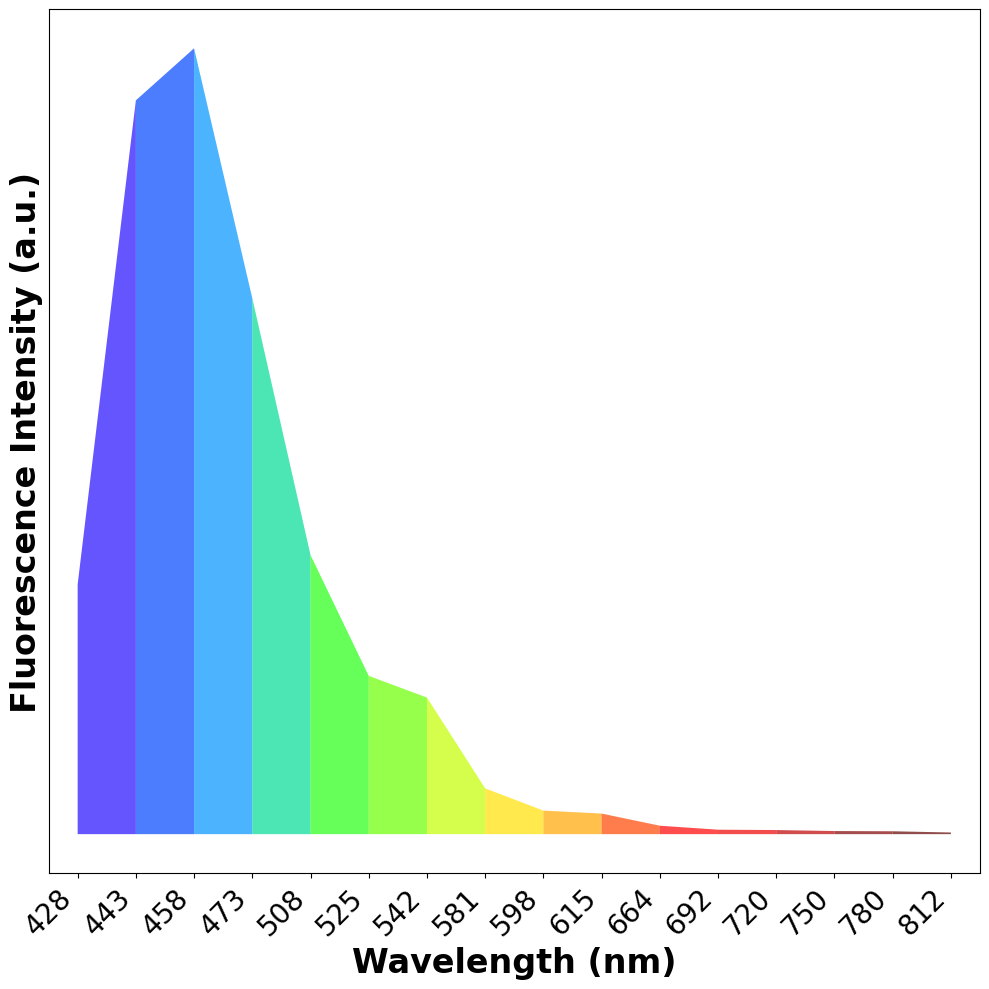

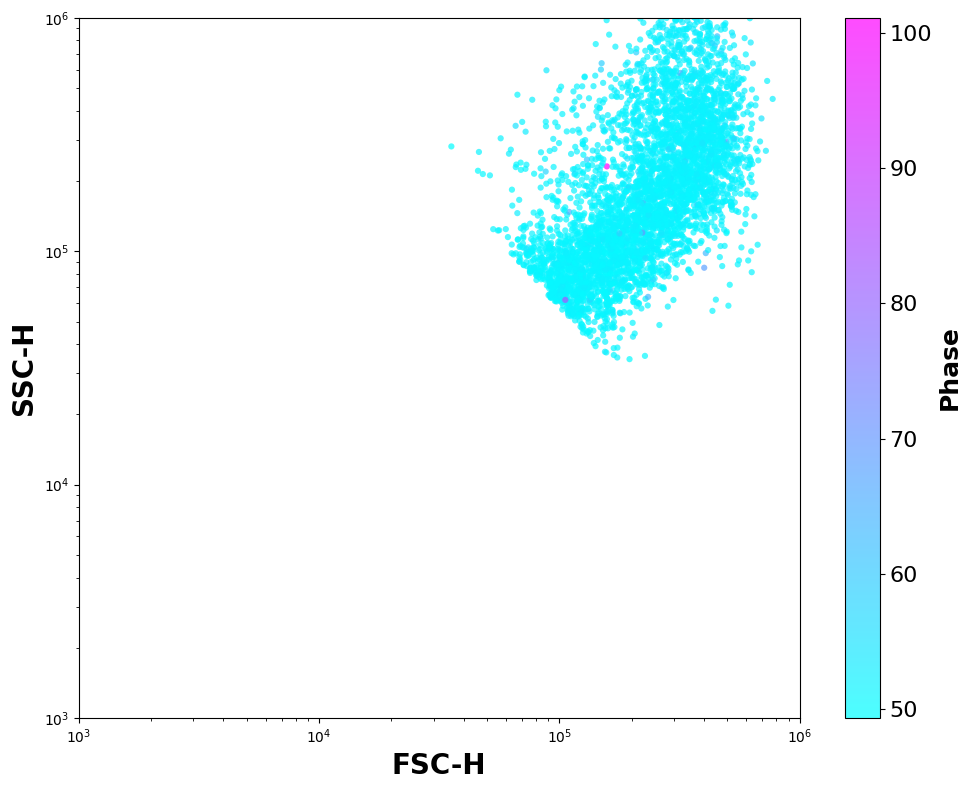

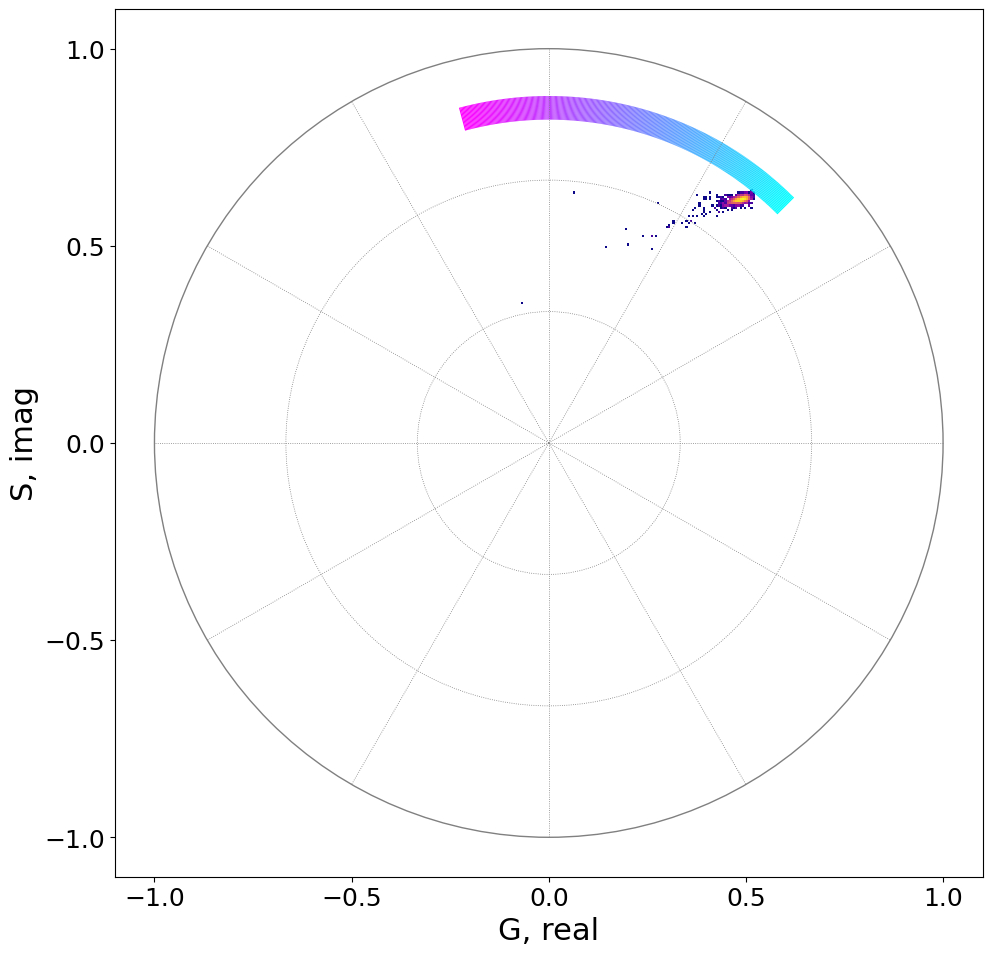

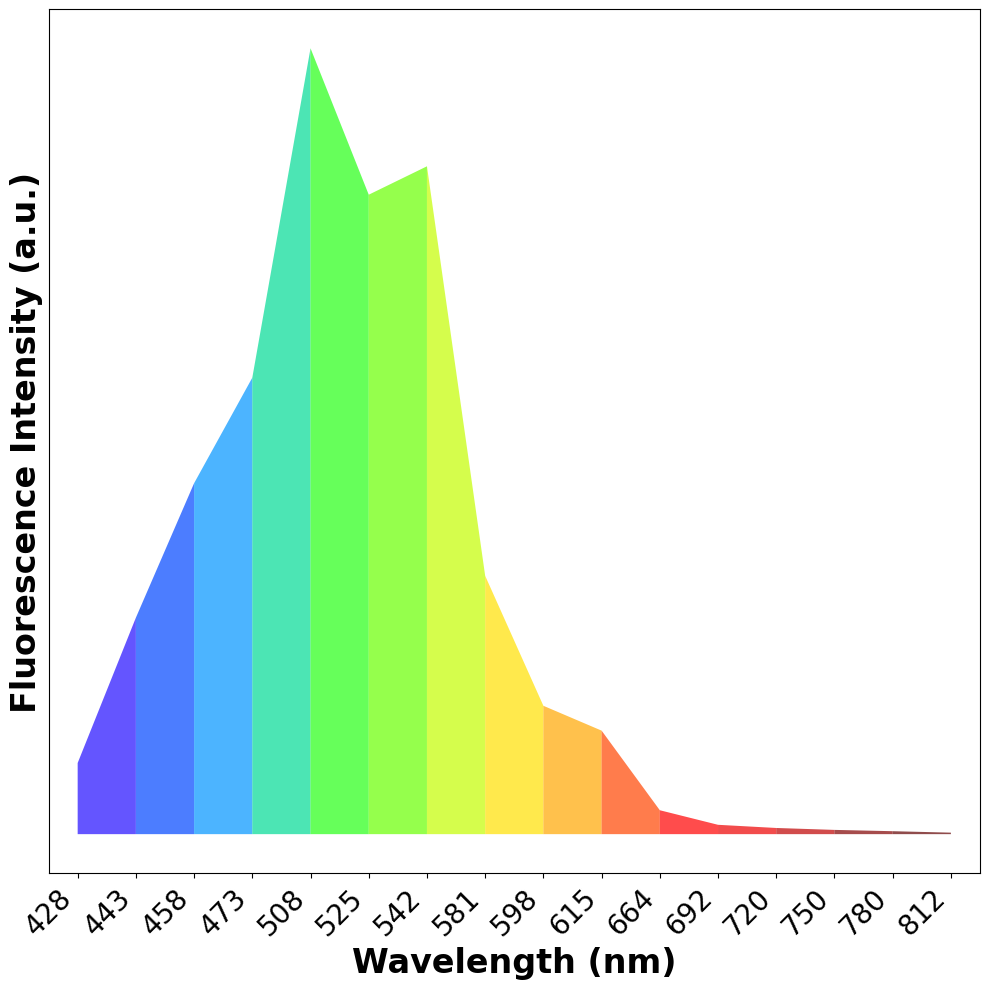

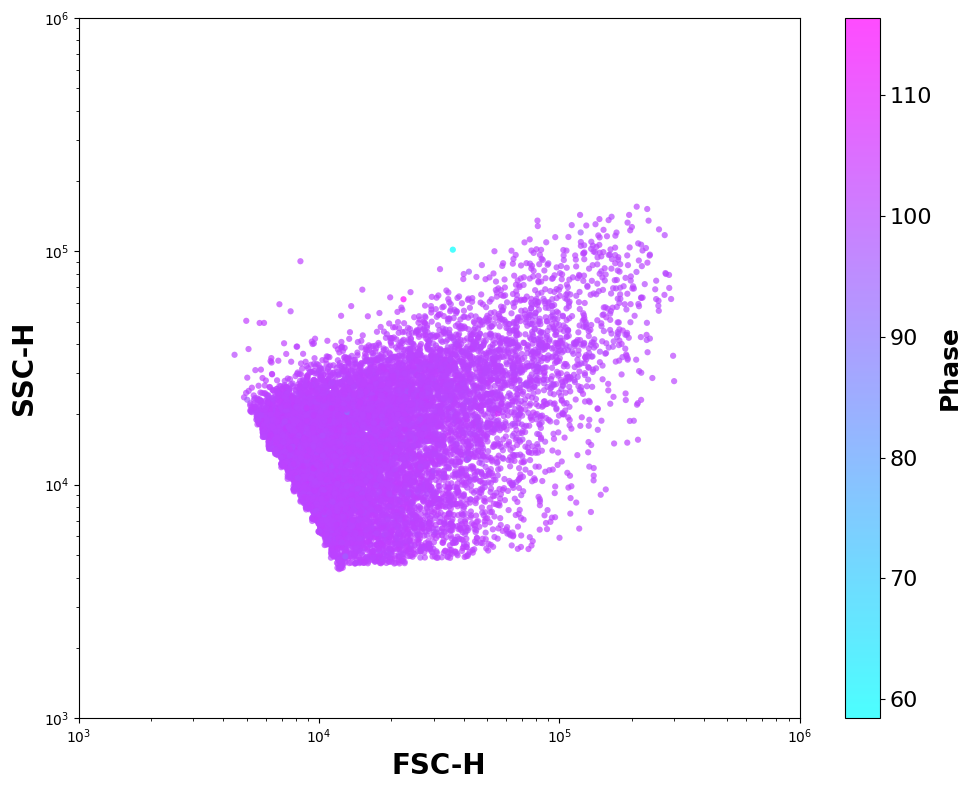

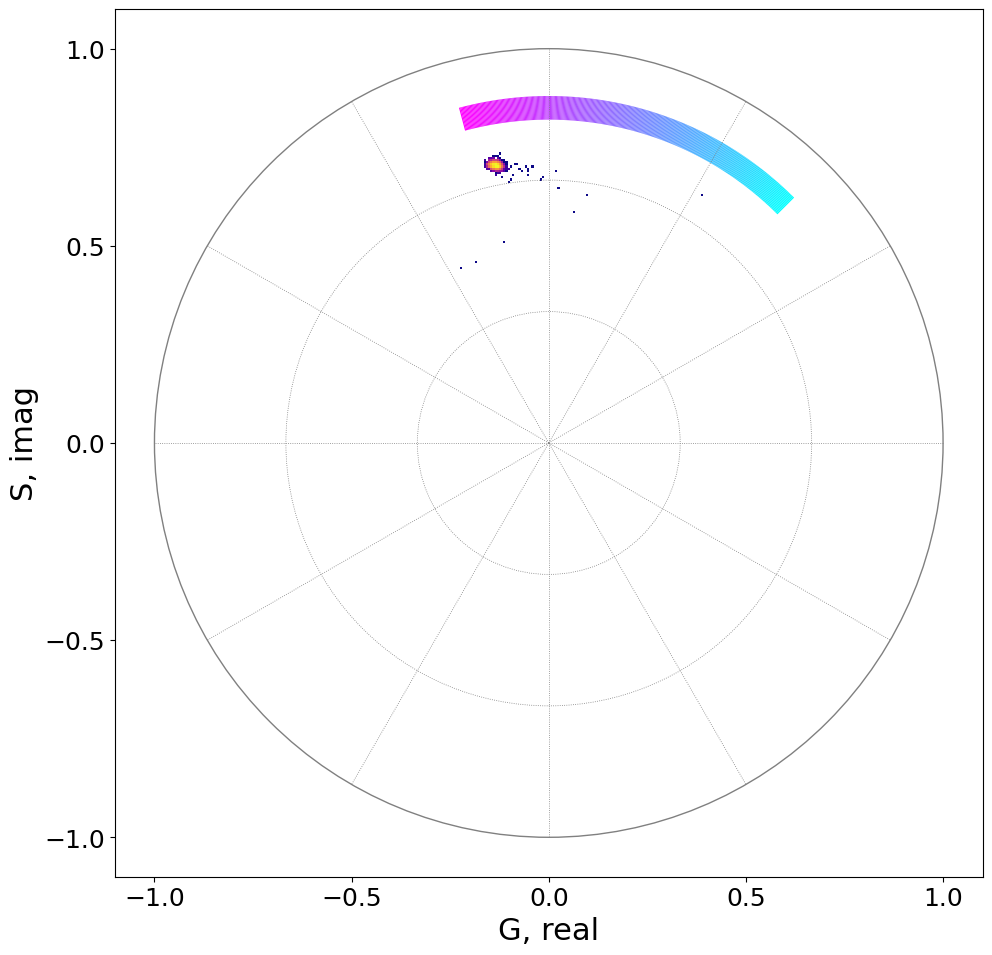

In [25]:
sfc_results = {}

for condition in CONDITIONS:
    cfg = SFC_INPUTS[condition]
    sample_name, fig_spec, fig_phase, fig_phasor, phase_map, mod_map = run_sfc_analysis(
        cfg["data_path"],
        cfg["filename"],
        SFC_WAVELENGTHS,
        phase_limits=(45, 105),
        phase_cmap="cool",
    )

    sfc_results[condition] = {
        "sample_name": sample_name,
        "fig_spec": fig_spec,
        "fig_phase": fig_phase,
        "fig_phasor": fig_phasor,
        "phase": phase_map,
        "modulation": mod_map,
    }

    print(f"SFC | condition: {condition} | sample: {sample_name}")

## Execute HSI Figure Generation (DPPC 0% and DOPC 0%)

This cell runs the full HSI workflow for both conditions and renders all generated HSI figures.

HSI | condition: DPPC 0% | sample: DPPC 0 Chol_4
HSI | condition: DOPC 0% | sample: DOPC 0 Chol_2


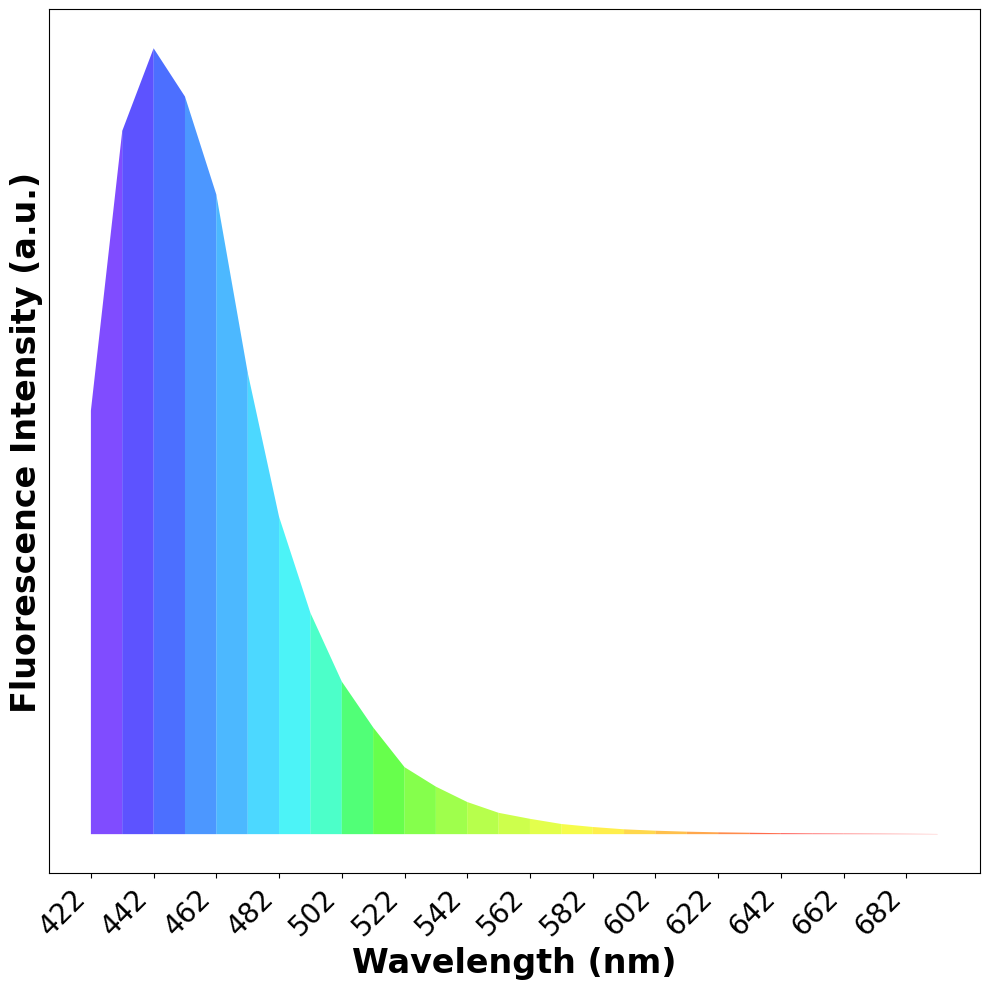

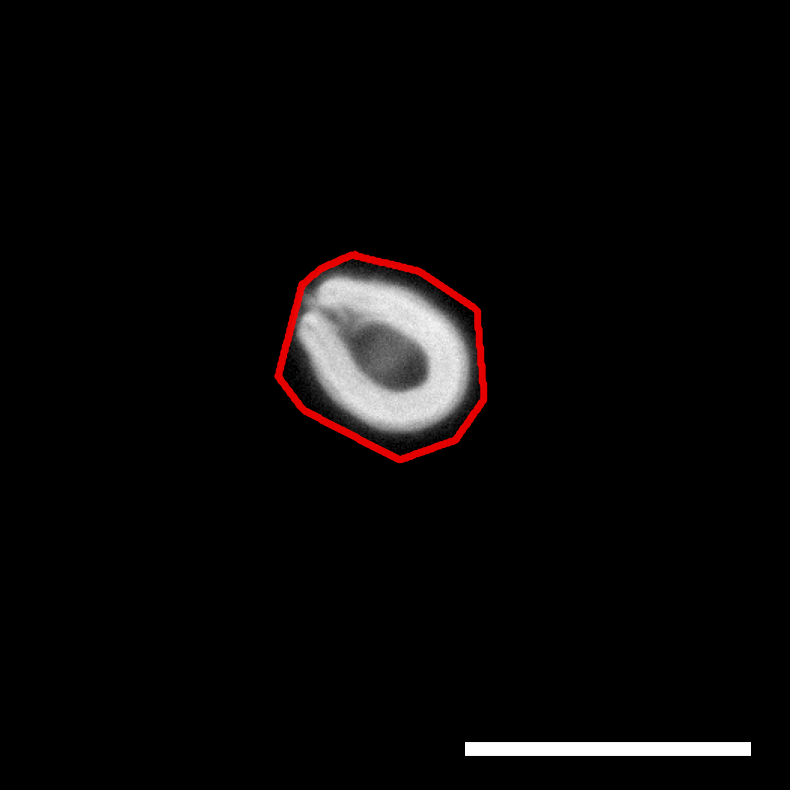

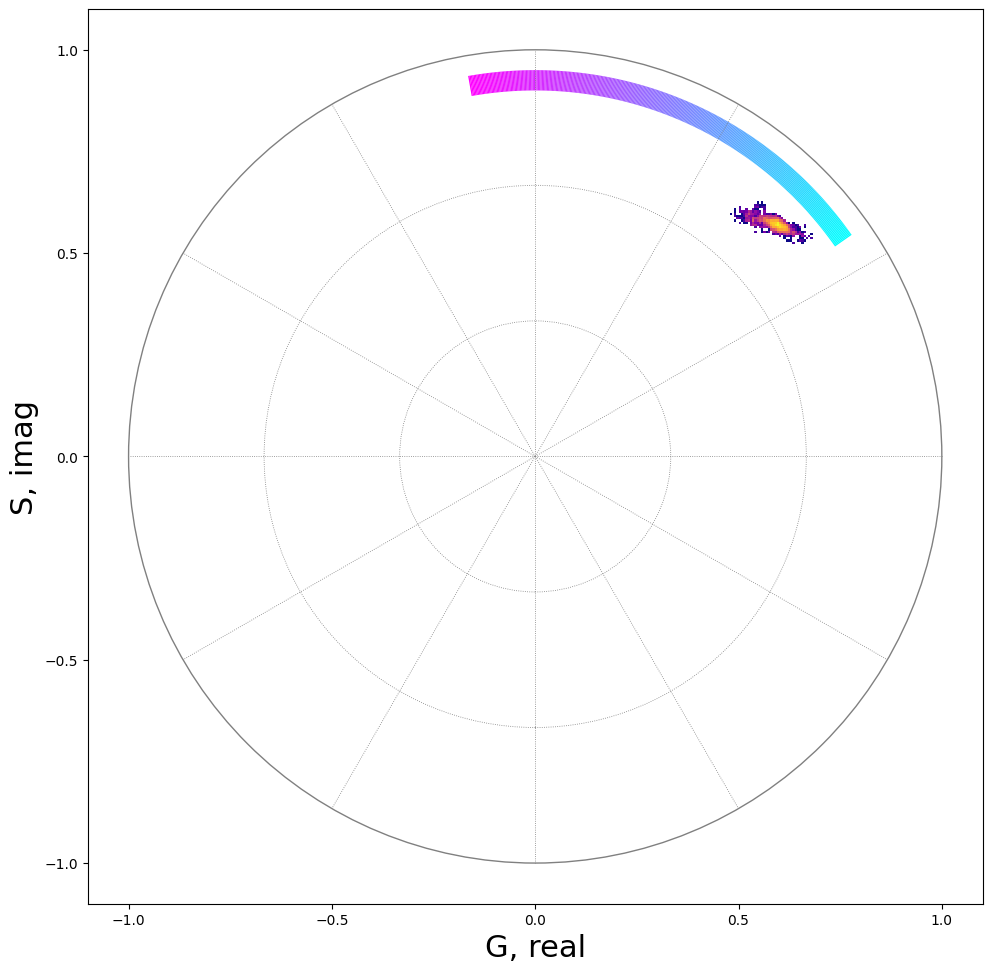

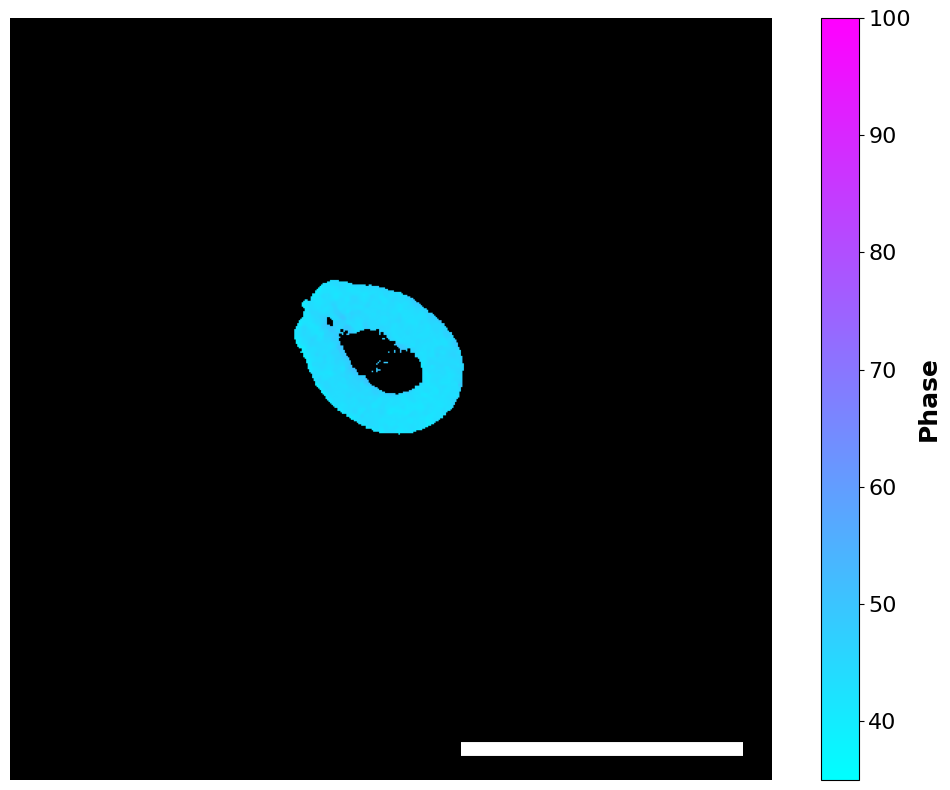

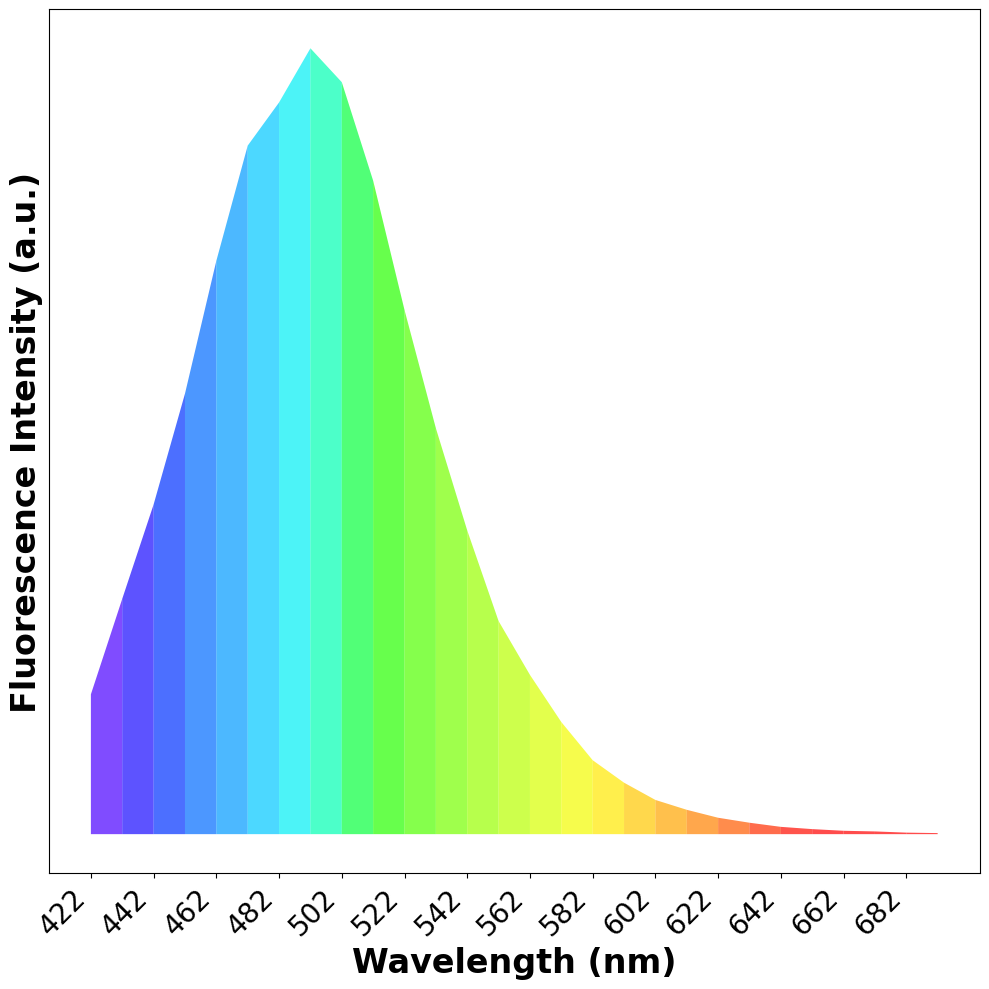

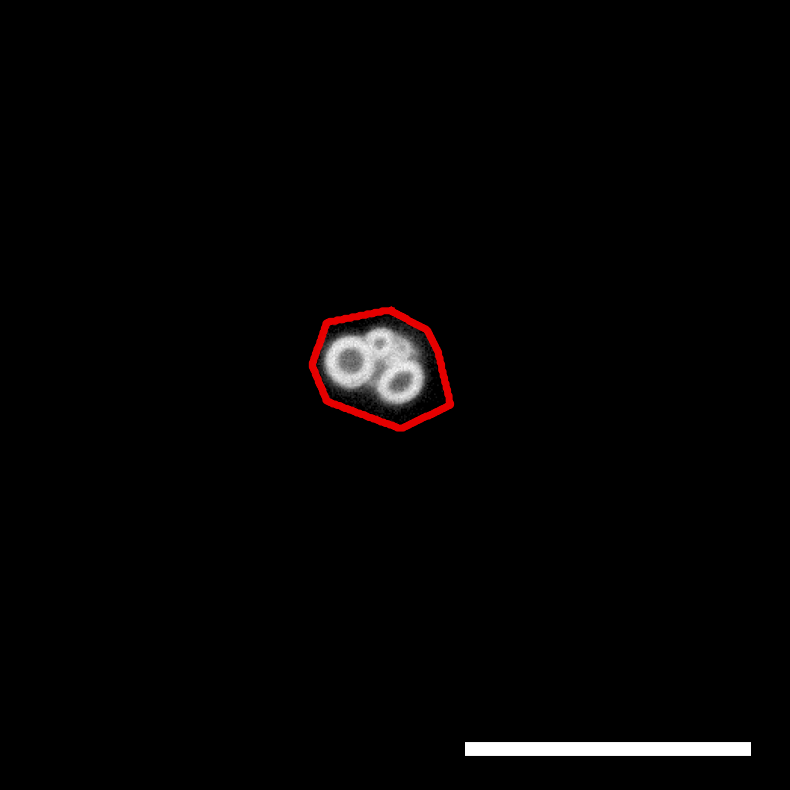

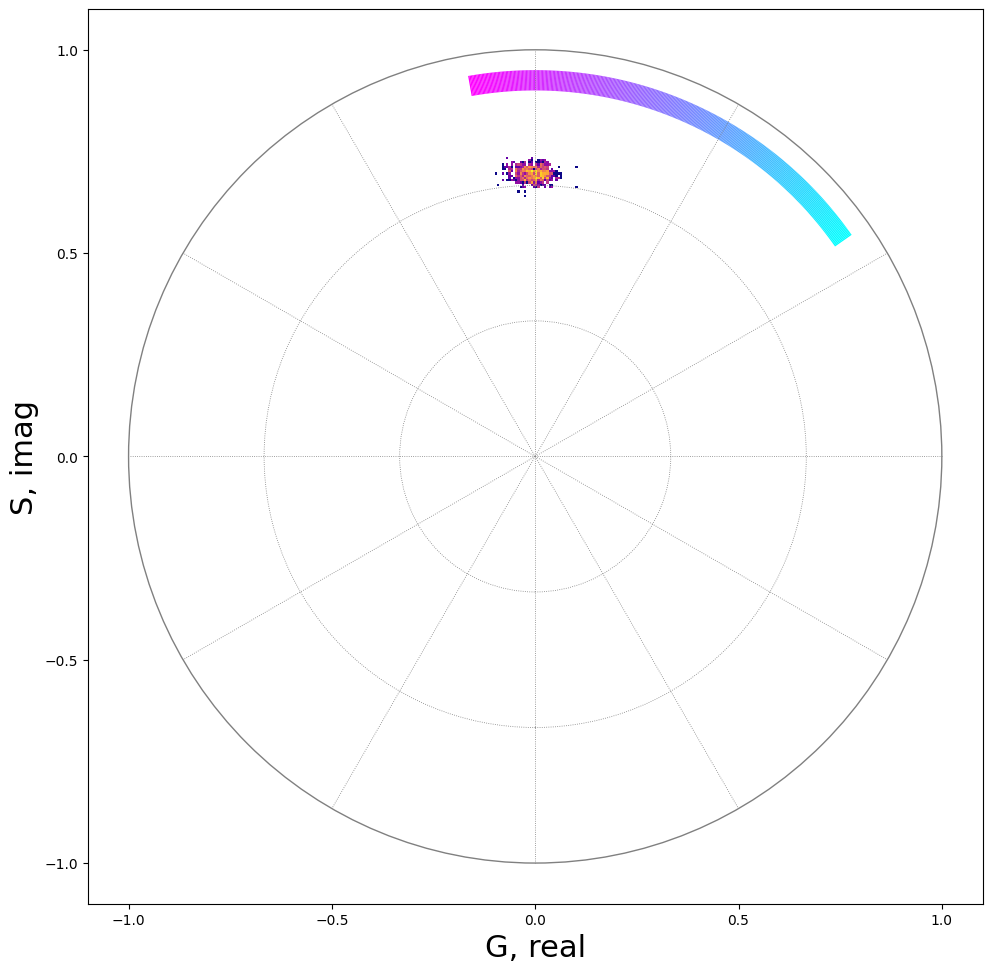

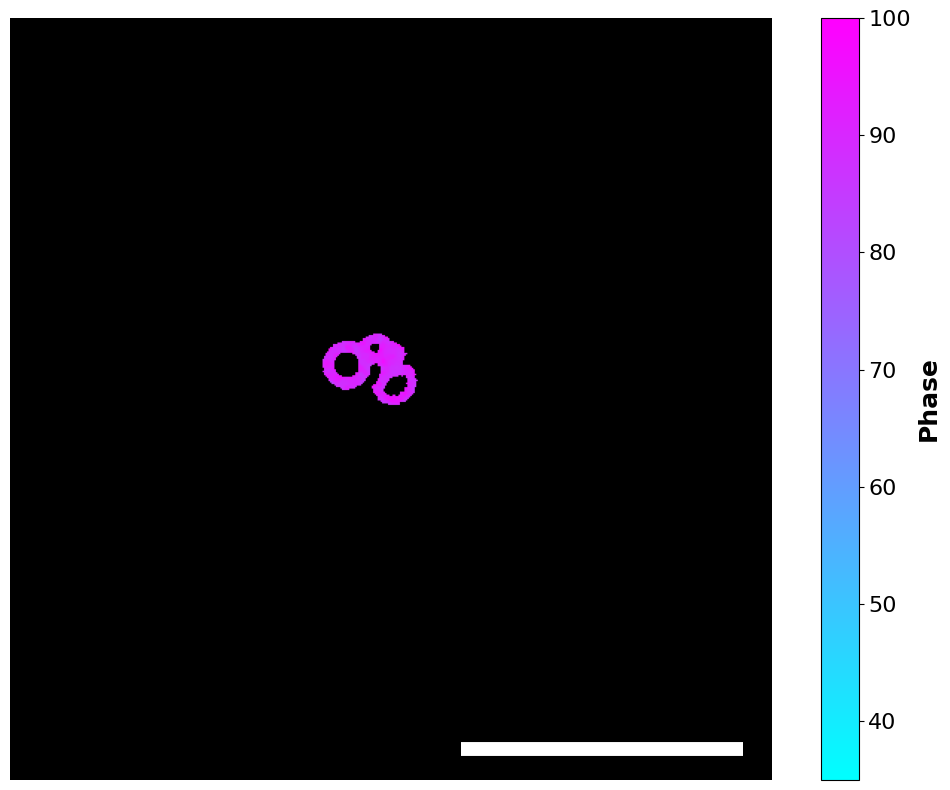

In [26]:
hsi_results = {}

for condition in CONDITIONS:
    cfg = HSI_INPUTS[condition]
    sample_name, fig_spec, fig_avg, fig_phasor, fig_phase, phase_map, mod_map = (
        run_hsi_analysis(
            cfg["data_path"],
            cfg["filename"],
            HSI_WAVELENGTHS,
            cfg["mask_path"],
            phase_limits=(35, 100),
            phase_cmap="cool",
        )
    )

    hsi_results[condition] = {
        "sample_name": sample_name,
        "fig_spec": fig_spec,
        "fig_avg": fig_avg,
        "fig_phasor": fig_phasor,
        "fig_phase": fig_phase,
        "phase": phase_map,
        "modulation": mod_map,
    }

    print(f"HSI | condition: {condition} | sample: {sample_name}")